## 1. Setup & Imports

Import libraries and configure the project root path to access `src/` modules.

In [1]:
import sys
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import re
import csv

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


## 2. Load Raw Data

Load the raw `nazario` CSV from the raw data directory and inspect its shape.

In [2]:
from src.config import RAW_DATA_DIR

csv.field_size_limit(50 * 1024 * 1024)
db = pd.read_csv(RAW_DATA_DIR / "nazario.csv")
db.shape


(1565, 7)

In [3]:
db.head(2)


,sender,receiver,date,subject,body,urls,label
0,Mail System Internal Data <MAILER-DAEMON@monke...,NaN,28 Sep 2017 09:57:25 -0400,DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA,This text is part of the internal format of yo...,1,1
1,cPanel <service@cpanel.com>,jose@monkey.org,"Fri, 30 Oct 2015 00:00:48 -0500",Verify Your Account,Business with \t\t\t\t\t\t\t\tcPanel & WHM \t...,1,1


In [4]:
db.isnull().sum()


sender       0
receiver    96
date         1
subject      4
body         0
urls         0
label        0
dtype: int64

In [5]:
db.info()


<class 'pandas.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sender    1565 non-null   str  
 1   receiver  1469 non-null   str  
 2   date      1564 non-null   str  
 3   subject   1561 non-null   str  
 4   body      1565 non-null   str  
 5   urls      1565 non-null   int64
 6   label     1565 non-null   int64
dtypes: int64(2), str(5)
memory usage: 85.7 KB


In [6]:
# check for empty string cells
for col in db.columns:
    empty = (db[col].astype(str).str.strip() == "").sum()
    if empty > 0:
        print(f"{col}: {empty} empty strings")


body: 2 empty strings


In [7]:
# combine subject + body into text, fill empty subject
db["subject"] = db["subject"].fillna("").astype(str).str.strip()
db["body"] = db["body"].fillna("").astype(str)
db["text"] = db["subject"] + " " + db["body"]
db["text"] = db["text"].str.strip()

print(f"Text samples after combine: {len(db)}")
print(f"Empty text count: {(db['text'] == '').sum()}")


Text samples after combine: 1565
Empty text count: 0


In [8]:
# urls column is binary, will recompute from text
db.drop(columns=["sender", "receiver", "date", "subject", "body", "urls"], inplace=True)
db.columns.tolist()


['label', 'text']

## 4. Feature Engineering

Extract numeric features from the raw text: URL count, exclamation/question marks, dollar signs, ALL-CAPS words, numbers, word count, and capitalisation ratio.

In [9]:
db["num_urls"]        = db["text"].str.findall(r'https?://\S+|www\.\S+').str.len()
db["num_exclamation"] = db["text"].str.count(r'!')
db["num_question"]    = db["text"].str.count(r'\?')
db["num_dollar"]      = db["text"].str.count(r'\$')
db["num_all_caps"]    = db["text"].str.findall(r'\b[A-Z]{2,}\b').str.len()
db["num_numbers"]     = db["text"].str.findall(r'\d+').str.len()
db["word_count"]      = db["text"].str.split().str.len()
caps   = db["text"].str.findall(r'[A-Z]').str.len()
letters = db["text"].str.findall(r'[A-Za-z]').str.len()
db["capital_ratio"]   = np.where(letters > 0, caps / letters, 0)


## 4b. Emoji Count Feature

Count the number of emoji characters in each email text.

In [10]:
import emoji

db["emoji_count"] = db["text"].apply(emoji.emoji_count)


## 5. Exploratory Data Analysis

Visualise the class distribution with a pie chart and compare average feature values between spam and ham emails.

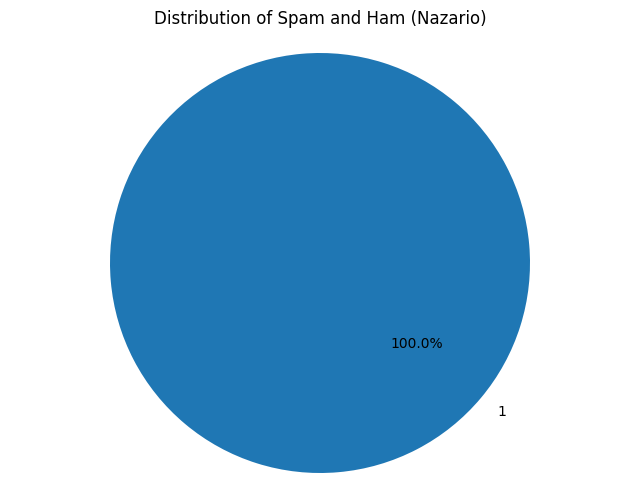

In [11]:
db['label'].value_counts()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.pie(db['label'].value_counts(), labels=db['label'].value_counts().index,
        autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Spam and Ham (Nazario)')
plt.axis('equal')
plt.show()


In [12]:
db.groupby("label")["emoji_count"].mean()


label
1    0.453674
Name: emoji_count, dtype: float64

In [13]:
db.groupby('label')['num_exclamation'].mean()


label
1    0.609585
Name: num_exclamation, dtype: float64

In [14]:
db.groupby('label')['num_dollar'].mean()


label
1    0.154633
Name: num_dollar, dtype: float64

In [15]:
db.groupby('label')['num_question'].mean()


label
1    1.316294
Name: num_question, dtype: float64

In [16]:
db.groupby('label')['num_all_caps'].mean()


label
1    10.681789
Name: num_all_caps, dtype: float64

In [17]:
db.groupby('label')['capital_ratio'].mean()


label
1    0.102697
Name: capital_ratio, dtype: float64

In [18]:
db.groupby('label')['num_numbers'].mean()


label
1    354.987859
Name: num_numbers, dtype: float64

In [19]:
db.groupby('label')['num_urls'].mean()


label
1    0.410224
Name: num_urls, dtype: float64

In [20]:
db.groupby('label')['word_count'].mean()


label
1    273.369968
Name: word_count, dtype: float64

In [21]:
db.info()


<class 'pandas.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   label            1565 non-null   int64  
 1   text             1565 non-null   str    
 2   num_urls         1565 non-null   int64  
 3   num_exclamation  1565 non-null   int64  
 4   num_question     1565 non-null   int64  
 5   num_dollar       1565 non-null   int64  
 6   num_all_caps     1565 non-null   int64  
 7   num_numbers      1565 non-null   int64  
 8   word_count       1565 non-null   int64  
 9   capital_ratio    1565 non-null   float64
 10  emoji_count      1565 non-null   int64  
dtypes: float64(1), int64(9), str(1)
memory usage: 134.6 KB


## 6. Deduplication

Remove duplicate rows based on the `text` column to avoid data leakage.

In [22]:
db.drop_duplicates(subset="text", inplace=True)
db.shape


(1564, 11)

## 7. Text Cleaning

Import the `clean_db_text` function for heavy-duty text cleaning (bracket/hex removal, normalisation).

In [ ]:
from src.preprocess import clean_db_text


## 7b. Apply Cleaner

Apply `clean_db_text` to every row and re-deduplicate after cleaning.

In [24]:
db["text"] = db["text"].apply(clean_db_text)
db.drop_duplicates(subset="text", inplace=True)
print(f"After cleaning: {db.shape}")


After cleaning: (1534, 11)


In [25]:
db["text"].iloc[0]


'don\'t delete this message -- folder internal data this text is part of the internal format of your mail folder and is not a real message it is created automatically by the mail system software if deleted important folder data will be lost and it will be re-created with the data reset to initial values from [email] fri jan [number] [number] [number] [phonenumber] return-path x-original-to [email] delivered-to [email] received from forwardbhostedemailcom (forwardbhostedemailcom [phonenumber] ) by lmonkeyorg (postfix) with esmtp id 180e6f [phonenumber] for ; fri [number] jan [phonenumber] [number] [number] - [phonenumber] (cst) received from smtpin10hostedemailcom ( [phonenumber] rfc [phonenumber] com [phonenumber] ) by ofarelay01bhostedemailcom (postfix) with smtp id 6e3bf34e368 for ; fri [number] jan [phonenumber] [number] [number] [phonenumber] (utc) x-forwarded-for [email] by hostedemail delivered-to [email] x-fda [phonenumber] water55_6b398d6d93b0f authentication-results authbhoste

## 8. Regex Cleanup

Remove noise tokens: `[NUMBER]` placeholders, underscores, repeated `-+=` characters, and angle brackets/slashes.

In [26]:
# remove [NUMBER] token (count is already in num_numbers feature)
db["text"] = db["text"].str.replace(r'\b\[NUMBER\]\b', '', regex=True)

# remove underscores
db["text"] = db["text"].str.replace("_", "", regex=False)

# remove repeated - + =
db["text"] = db["text"].str.replace(r'[-+=]{2,}', ' ', regex=True)

# remove > < / 
db["text"] = db["text"].str.replace(r'[<>/]', '', regex=True)


## 9. Advanced Text Processing (Optional)

Apply stopword removal and stemming via `process_text_advanced`. (Cell may be left unexecuted.)

In [ ]:
from src.preprocess import process_text_advanced
db["text"] = db["text"].apply(process_text_advanced)


In [29]:
db["text"].iloc[0]


'delet messag folder intern data text part intern format mail folder real messag creat automat mail system softwar delet import folder data lost re-creat data reset initi valu [email] fri jan [number] [number] [number] [phonenumber] return-path x-original-to [email] delivered-to [email] receiv forwardbhostedemailcom forwardbhostedemailcom [phonenumber] lmonkeyorg postfix esmtp id 180e6f [phonenumber] fri [number] jan [phonenumber] [number] [number] [phonenumber] cst receiv smtpin10hostedemailcom [phonenumber] rfc [phonenumber] com [phonenumber] ofarelay01bhostedemailcom postfix smtp id 6e3bf34e368 fri [number] jan [phonenumber] [number] [number] [phonenumber] utc x-forwarded-for [email] hostedemail delivered-to [email] x-fda [phonenumber] water556b398d6d93b0f authentication-result authbhostedemailcom dmarc=non headerfrom=croydonpodiatrygroupcomau authentication-result authbhostedemailcom dkim=non reason="no signature" dkim-adsp=non insecur policy dkim-atps=neutr x-spam-summari [number]

In [30]:
db.shape


(1534, 11)

In [31]:
db["label"].value_counts()


label
1    1534
Name: count, dtype: int64

## 10. Save Cleaned Dataset

Write the cleaned and feature-engineered dataset to the processed data directory.

In [32]:
from src.config import PROCESSED_DATA_DIR
db.to_csv(PROCESSED_DATA_DIR / "cleaned_nazario.csv", index=False)
print(f"Saved to {PROCESSED_DATA_DIR / 'cleaned_nazario.csv'}")


Saved to C:\Users\aungm\university\computing\cos30049-email-spam-detection\data\processed\cleaned_nazario.csv
